First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
            math    science    english    

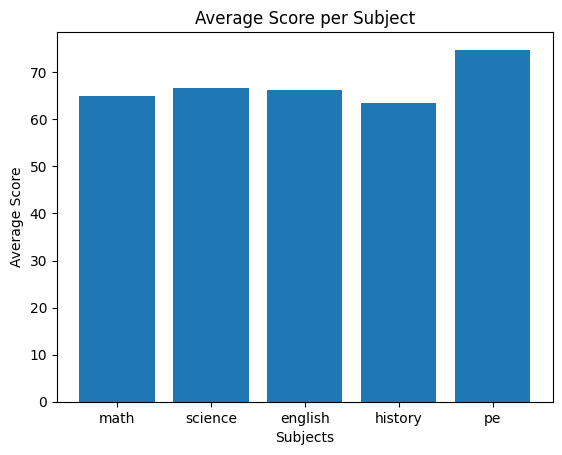

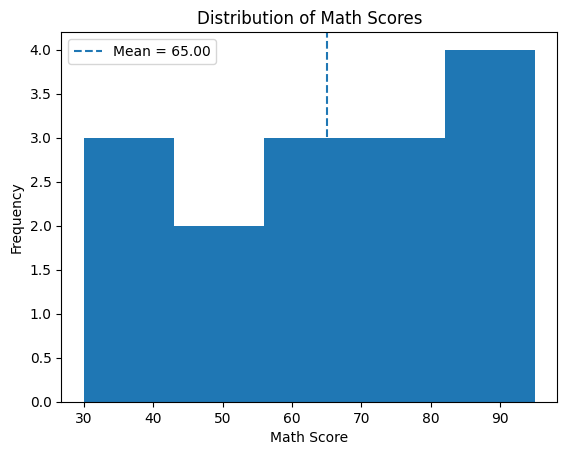

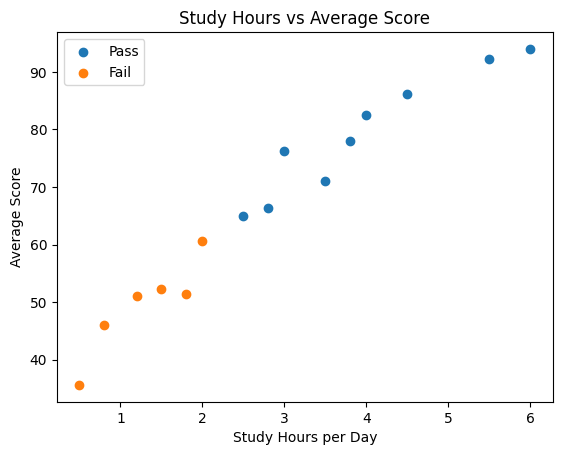

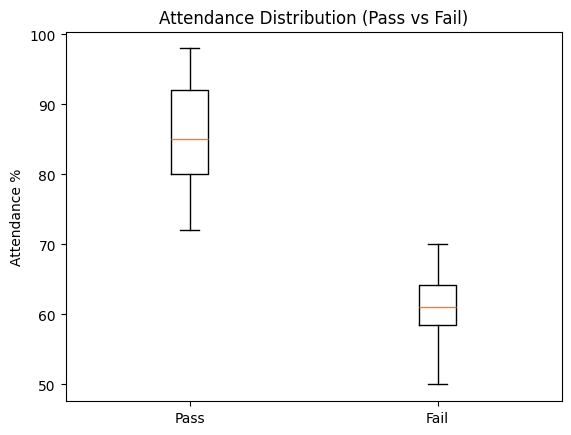

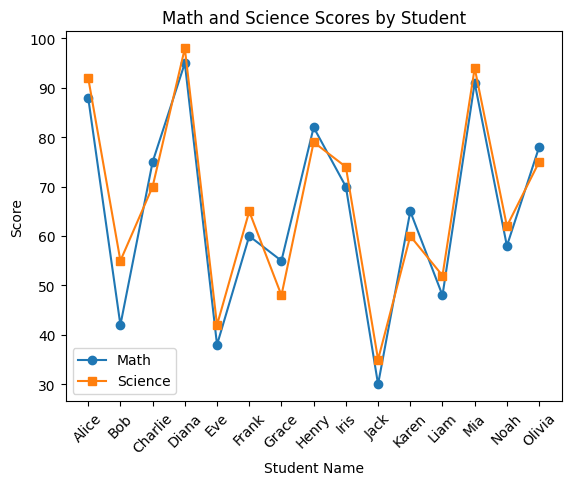

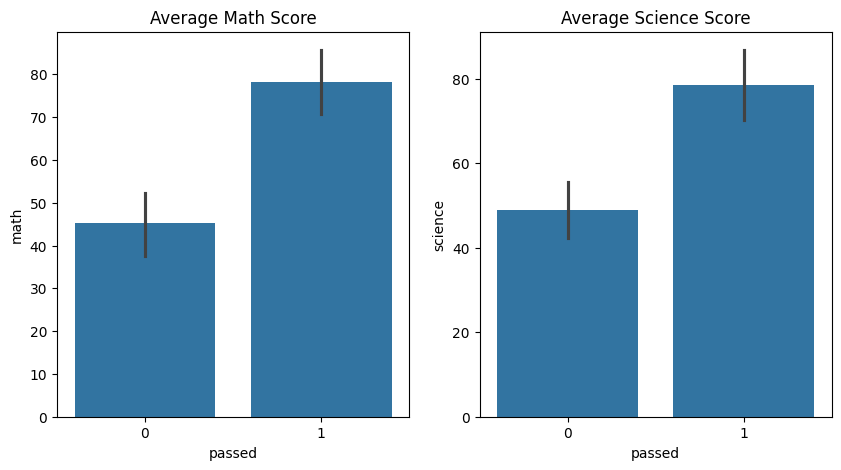

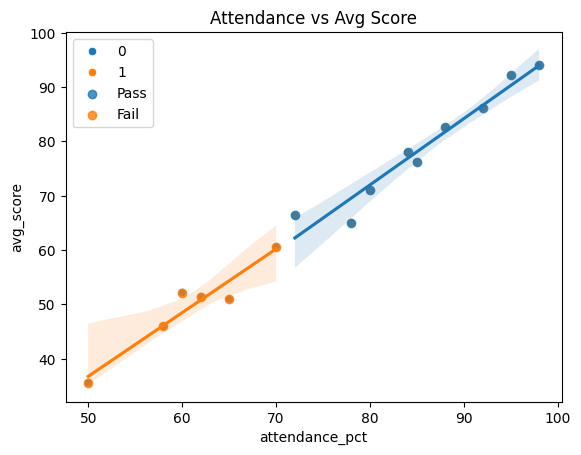


Training Accuracy: 1.0
Test Accuracy: 1.0

Predictions:
Jack | Actual: 0 | Predicted: 0 | ✅ Correct
Liam | Actual: 0 | Predicted: 0 | ✅ Correct
Alice | Actual: 1 | Predicted: 1 | ✅ Correct

Feature Importance:
               Feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


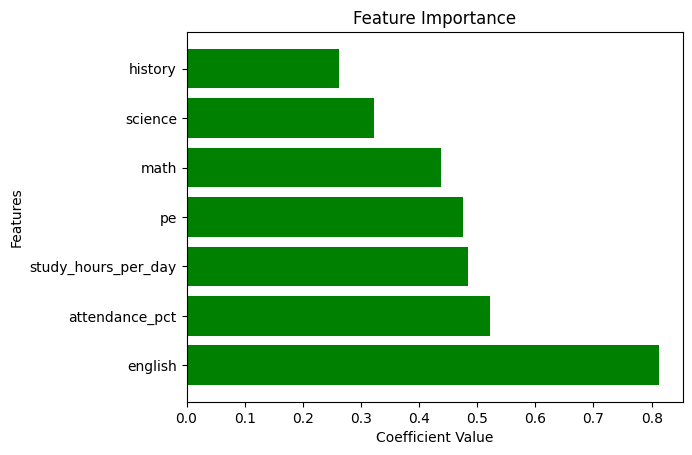


New Student Prediction:
Prediction: Pass
Probability: [0.09203526 0.90796474]


In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())

# ==============================
# BASIC INFO
# ==============================
print("\nShape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

print("\nPass/Fail Count:")
print(df['passed'].value_counts())

# ==============================
# AVERAGE SCORES (PASS VS FAIL)
# ==============================
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores (Passed students):")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage scores (Failed students):")
print(df[df['passed'] == 0][subject_cols].mean())

# ==============================
# TOP STUDENT
# ==============================
df['avg_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]
print("\nTop student:")
print(top_student[['name', 'avg_score']])

# ==============================
# TASK 2 — MATPLOTLIB
# ==============================

# 1. Bar Chart
plt.figure()
plt.bar(subject_cols, df[subject_cols].mean())
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.show()

# 2. Histogram
mean_math = df['math'].mean()

plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 3. Scatter Plot
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.show()

# 4. Box Plot
pass_attendance = pass_df['attendance_pct'].tolist()
fail_attendance = fail_df['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])
plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance %")
plt.show()

# 5. Line Plot
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.xticks(rotation=45)
plt.title("Math and Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.show()

# ==============================
# TASK 3 — SEABORN
# ==============================

# 6. Bar Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score")

plt.show()

# 7. Scatter + Regression
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=pass_df, x='attendance_pct', y='avg_score', label='Pass')
sns.regplot(data=fail_df, x='attendance_pct', y='avg_score', label='Fail')

plt.title("Attendance vs Avg Score")
plt.legend()
plt.show()

# Seaborn vs Matplotlib comment
# Seaborn is easier for statistical and grouped plots with less code.
# Matplotlib gives more control but requires more manual customization.

# ==============================
# TASK 4 — MACHINE LEARNING
# ==============================

# Prepare Data
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("\nTraining Accuracy:", train_acc)

# Evaluate Model
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

print("\nPredictions:")
for i, pred in enumerate(y_pred):
    actual = y_test.iloc[i]
    name = df.loc[X_test.index[i], 'name']
    status = "✅ Correct" if pred == actual else "❌ Wrong"
    print(f"{name} | Actual: {actual} | Predicted: {pred} | {status}")

# Feature Importance
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

feature_importance['Abs'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs', ascending=False)

print("\nFeature Importance:")
print(feature_importance[['Feature','Coefficient']])

# Plot feature importance
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]

plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

# ==============================
# BONUS — NEW STUDENT
# ==============================
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]],
                           columns=X.columns)

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

print("\nNew Student Prediction:")
print("Prediction:", "Pass" if prediction == 1 else "Fail")
print("Probability:", probability)